<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EKSPERIMEN 1: GAUSSIAN NAIVE BAYES (DATA NUMERIK – IRIS)**

**Import Library**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

**Load Dataset**

In [12]:
data = pd.read_csv("iris_naive_bayes GaussianNB.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

Preview data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Checking for missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Checking for duplicate rows before dropping:
1

Checking for duplicate rows after dropping:
0


**Split Data**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (119, 4)
Shape of X_test: (30, 4)
Shape of y_train: (119,)
Shape of y_test: (30,)


In [14]:
X = data.drop('target', axis=1) # Features
y = data['target'] # Target variable

**Latih Model**

In [15]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

**Evaluasi Model**

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



<Axes: >

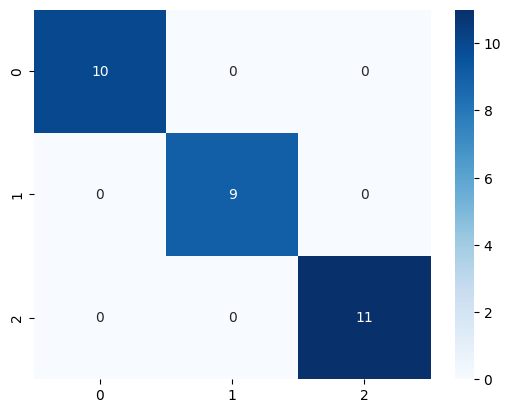

In [16]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

**EKSPERIMEN 2: MULTINOMIAL NAIVE BAYES (DATA TEKS – SPAM EMAIL)**

Import Library


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

Load Dataset

In [39]:
data = pd.read_csv("spam_email Multinomial Naive Bayes.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

print("\nLabel distribution:")
print(data['label'].value_counts())

Preview data:


,text,label
0,Dapatkan promo kredit tanpa agunan sekarang juga,spam
1,Segera klaim hadiah undian miliaran rupiah,spam
2,"Diskon besar-besaran hanya hari ini, klik link...",spam
3,Promo terbatas! bonus saldo setelah transfer p...,spam
4,Penawaran investasi dengan keuntungan 20% per ...,spam



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20 non-null     object
 1   label   20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes
None

Checking for missing values:
text     0
label    0
dtype: int64

Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0

Label distribution:
label
spam    10
ham     10
Name: count, dtype: int64


Preprocessing & Vectorization

In [22]:
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(data['text'])
y = data['label']

Split Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16, 118)
Shape of X_test: (4, 118)
Shape of y_train: (16,)
Shape of y_test: (4,)


Latih Model

In [27]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Evaluasi Model

Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      0.50      0.67         2
        spam       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



<Axes: >

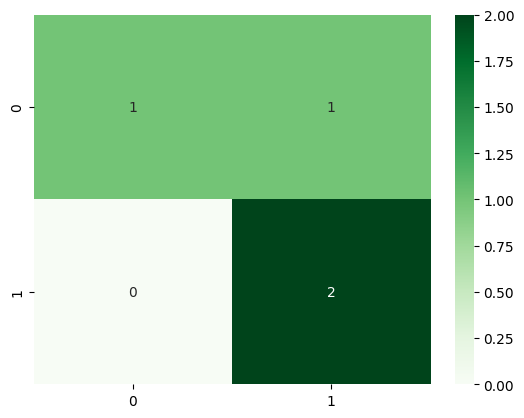

In [28]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')

**EKSPERIMEN 3: BERNOULLI NAIVE BAYES (DATA BINER – SENTIMEN SEDERHANA)**

Import Library


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

Load Dataset

In [30]:
data = pd.read_csv("bernoulli_sentiment.csv")
print("Preview data:")
display(data.head())

print("\nInfo kolom:")
print(data.info())

print("\nChecking for missing values:")
print(data.isnull().sum())

print("\nChecking for duplicate rows before dropping:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("\nChecking for duplicate rows after dropping:")
print(data.duplicated().sum())

Preview data:


,text,label
0,film ini sangat bagus dan menyenangkan,positif
1,saya puas dengan pelayanan hari ini,positif
2,produk ini berkualitas dan sesuai harga,positif
3,pengiriman cepat dan kemasan rapi,positif
4,saya merekomendasikan toko ini,positif



Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16 non-null     object
 1   label   16 non-null     object
dtypes: object(2)
memory usage: 388.0+ bytes
None

Checking for missing values:
text     0
label    0
dtype: int64

Checking for duplicate rows before dropping:
0

Checking for duplicate rows after dropping:
0


**Buat Dataset Sederhana**

In [31]:
data = {
    'text': [
        'film ini bagus', 'saya suka produk ini', 'pelayanan cepat dan ramah',
        'film ini jelek', 'saya kecewa', 'produk buruk dan lambat'
    ],
    'label': ['positif', 'positif', 'positif', 'negatif', 'negatif', 'negatif']
}
df = pd.DataFrame(data)

Representasi Biner

In [32]:
cv = CountVectorizer(binary=True)
X = cv.fit_transform(df['text'])
y = df['label']

Split Data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4, 14)
Shape of X_test: (2, 14)
Shape of y_train: (4,)
Shape of y_test: (2,)


Latih Model

In [37]:
model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB()

Evaluasi Model

Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

     negatif       0.00      0.00      0.00       0.0
     positif       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

<Axes: >

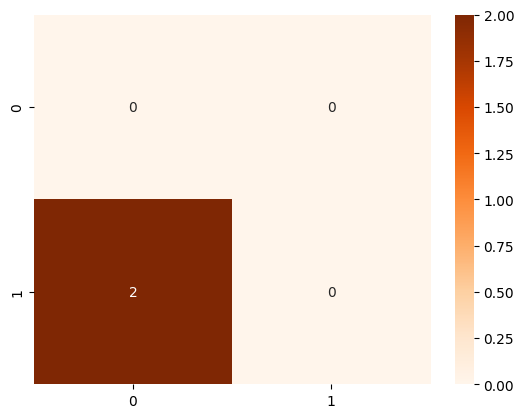

In [38]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges')